In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
from tqdm import tqdm

eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_model/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [ ]:
def plot_fun(data,n,cell_no):
    df = data[data["Cycle number"]==n]
    df= df.reset_index(drop=True)
    fig,ax = plt.subplots(2,2,figsize=(8,6))
    ax1 = ax.flat[0]
    ax1.plot(df["Time [s]"],df["Voltage [V]"])
    ax1.set_ylabel("Voltage [V]")
    ax1.set_xlabel("Time [s]")
    ax2 = ax.flat[2]
    ax2.plot(df["Time [s]"],df["Current [mA]"])
    ax2.set_ylabel("Current [mA]")
    ax2.set_xlabel("Time [s]")
    ax3 = ax.flat[1]
    ax3.plot(df["Time [s]"],df["Expansion [mu m]"])
    ax3.set_ylabel(r"Expansion [$\mu$m]")
    ax3.set_xlabel("Time [s]")
    ax4 = ax.flat[3]
    ax4.plot(df["Time [s]"],df["Temperature [C]"])
    ax4.set_ylabel(r"Temperature [$^\circ$C]")
    ax4.set_xlabel("Time [s]")
    fig.suptitle(f"Cell: {cell_no}, Cycle #{n}")
    fig.tight_layout()
    return fig

In [11]:
eSOH_DIR

'../data/esoh_R/'

In [15]:
cell = 1
dfa = []
for cell in range(1,26):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(eSOH_DIR+"aging_param_cell_"+cell_no+".csv")
    data["Cell"] = cell
    data["RPT"] = data.index +1
    dfa.append(data)

In [17]:
df1 = pd.concat(dfa)
df1.to_csv("deepSOH_data.csv")

In [2]:
def load_cycling_data_dh(cell,eSOH_DIR,oCV_DIR,cyc_DIR,cyc_no):
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    cycles = np.array(dfe_0['N'].astype('int'))+1
    cycles = cycles[1:]
    # print(cell_no)
    cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
    if cell == 1:
        offset = 12
    else:
        offset = 0
    if len(cycles) == cyc_no+1:
        N1 = cyc_data_raw1["Cycle number"].iloc[-1]-offset
    else:
        N1 = cycles[cyc_no]
    print(N1)
    cyc_data_raw = cyc_data_raw1[ cyc_data_raw1['Cycle number'] == N1 ]
    cyc_data = cyc_data_raw.reset_index(drop=True)
    t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
    t_c1 = t_c1.values
    I_c1 = cyc_data['Current [mA]']/1000
    I_c1 = I_c1.values
    V_c1 = cyc_data['Voltage [V]']
    V_c1 = V_c1.values
    E_c1 = cyc_data["Expansion [mu m]"]
    E_c1 = E_c1.values
    idx_I = np.where(np.sign(I_c1[:-1]) != np.sign(I_c1[1:]))[0] 
    idx_I = idx_I[idx_I>50]
    t = t_c1[idx_I[0]:]-t_c1[idx_I[0]]
    V = V_c1[idx_I[0]:]
    I = I_c1[idx_I[0]:]
    E = E_c1[idx_I[0]:]
    # t = t_c1
    # V = V_c1
    # I = I_c1
    Q = -1*integrate.cumtrapz(I,t, initial=0)/3600 #Ah
    
    return t,V,I,Q,E

In [3]:
cell = 4
t1,V1,I1,Q1,E1 = load_cycling_data_dh(cell,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t2,V2,I2,Q2,E2 = load_cycling_data_dh(cell,eSOH_DIR,oCV_DIR,cyc_DIR,6)

42
288


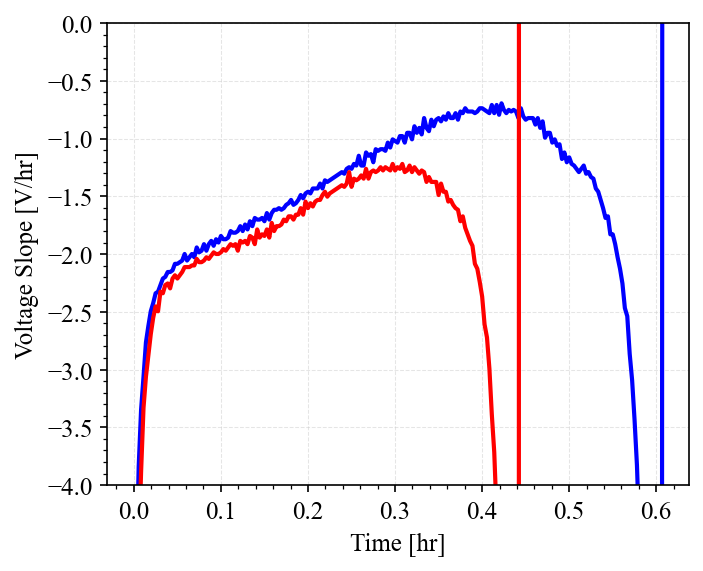

In [64]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax1 = ax
ax1.plot(t1[:-1]/3600,np.diff(V1)*3600/np.diff(t1),'b')
ax1.plot(t2[:-1]/3600,np.diff(V2)*3600/np.diff(t2),'r')
ax1.set_xlabel("Time [hr]")
ax1.set_ylabel("Voltage Slope [V/hr]")
ax1.set_ylim([-4,0])
fig.set_facecolor("white")
plt.savefig("voltage_slope.png")

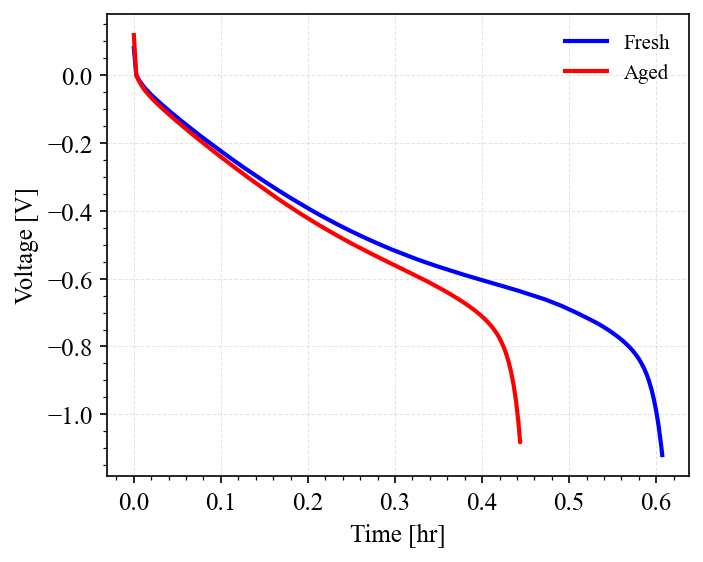

In [68]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax1 = ax
ax1.plot(t1/3600,V1-V1[1],'b')
ax1.plot(t2/3600,V2-V2[1],'r')
ax1.set_xlabel("Time [hr]")
ax1.set_ylabel("Voltage [V]")
ax1.legend(["Fresh","Aged"])
fig.set_facecolor("white")
plt.savefig("voltage_linedup.png")

In [6]:
5*3.72/1.64

11.341463414634148

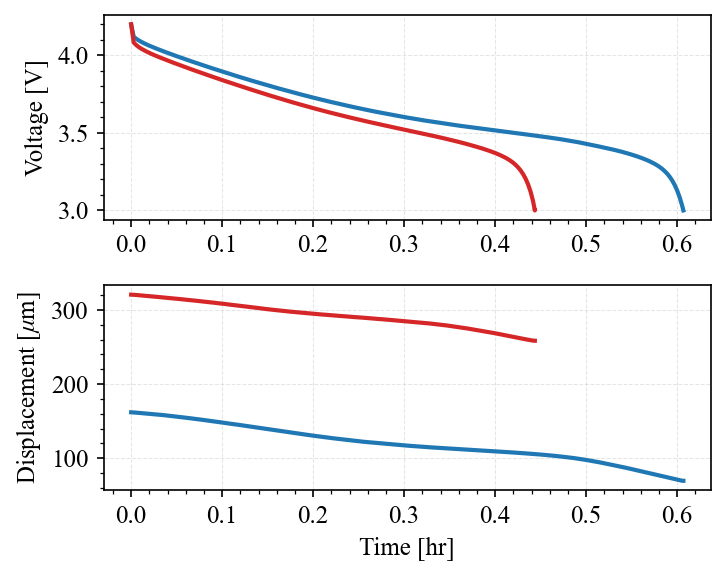

In [13]:
fig,ax = plt.subplots(2,1,figsize=(5,4))
ax1 = ax.flat[0]
ax1.plot(t1/3600,V1,'tab:blue')
ax1.plot(t2/3600,V2,'tab:red')
# ax1.set_xlabel("Time [hr]")
ax1.set_ylabel("Voltage [V]")
# ax1.legend(["Fresh","Aged"])
ax2 = ax.flat[1]
ax2.plot(t1/3600,E1,'tab:blue')
ax2.plot(t2/3600,E2,'tab:red')
ax2.set_xlabel("Time [hr]")
ax2.set_ylabel(r"Displacement [$\mu$m]")
fig.tight_layout()
fig.set_facecolor("white")
plt.savefig("vol_exp_fresh_aged.png")

In [19]:
for cell in range(26,36):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(eSOH_DIR+"aging_param_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    Ia = data["Current [mA]"].to_numpy()/1000
    ta = data["Time [s]"].to_numpy()
    AhTh = integrate.cumtrapz(abs(Ia), ta)/3600
    AhTh = np.append(AhTh,AhTh[-1])
    data["AhTh"] = AhTh
    Q_app = []
    max_exp = []
    min_exp = []
    Rs = []
    AhT = []
    for n in tqdm(N1):
        df = data[data["Cycle number"]==n]
        qmax = round(max(df["Capacity [Ah]"]),2)
        Q_app.append(qmax)
        emax = round(max(df["Expansion [mu m]"].fillna(0)),1)
        max_exp.append(emax)
        emin = round(min(df["Expansion [mu m]"].fillna(0)),1)
        min_exp.append(emin)
        AhT.append(round(df["AhTh"].iloc[0],1))
        t = df["Time [s]"].to_numpy()
        V = df["Voltage [V]"].to_numpy()
        I = df["Current [mA]"].to_numpy()/1000
        try:
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0))[0]
            idx = idxi1[0]
            R = (V[idx+1] - V[idx])/(I[idx+1] - I[idx])
            Rs.append(round(R,5))
        except:
            Rs.append(np.NaN)
    N = [n+1 for n in N1]
    dfs = pd.DataFrame({"N":N,"AhTh":AhT,"App Cap [Ah]":Q_app,"Min Exp [mu m]":min_exp,"Max Exp [mu m]":max_exp,"Rs [ohm]":Rs})
    mexp = round(dfs["Min Exp [mu m]"].iloc[0],1)
    dfs["Min Exp [mu m]"] = dfs["Min Exp [mu m]"] - mexp
    dfs["Min Exp [mu m]"] = dfs["Min Exp [mu m]"].round(1)
    dfs["Max Exp [mu m]"] = dfs["Max Exp [mu m]"] - mexp
    dfs["Max Exp [mu m]"] = dfs["Max Exp [mu m]"].round(1)
    dfs.to_csv(eSOH_DIR + "aging_param_cell_cyc_"+cell_no+".csv")

100%|██████████| 221/221 [00:00<00:00, 370.83it/s]


In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(N,Q_app,'o')
ax.set_xlabel("Cycle Number")
ax.set_ylabel("Apparent Capacity [Ah]")
ax.set_title("Apparent Capacity 1 psi Cell")
plt.savefig(fig_DIR + "Apparent Cap.png")

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(N,min_exp,'o')
ax.plot(N,max_exp,'o')
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"Expansion [$\mu$m]")
ax.set_title("Expansion 1 psi Cell")
ax.legend(["Min","Max"])
plt.savefig(fig_DIR + "Expansion.png")

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
# ax.plot(data["Time [s]"],data["Capacity [Ah]"])
ax.plot(data["Time [s]"],data["Q [Ah]"])

In [ ]:

df= df.reset_index(drop=True)
fig,ax = plt.subplots(2,1,figsize=(4,6))
ax1 = ax.flat[0]
ax1.plot(t,V)
ax1.plot(t[idx],V[idx],"rx")
ax1.plot(t[idx+1],V[idx+1],"rx")
ax1.set_ylabel("Voltage [V]")
ax1.set_xlabel("Time [s]")
ax2 = ax.flat[1]
ax2.plot(t,I)
ax2.plot(t[idx],I[idx],"rx")
ax2.plot(t[idx+1],I[idx+1],"rx")
ax2.set_ylabel("Current [A]")
ax2.set_xlabel("Time [s]")
fig.suptitle(f"Cell: {cell_no}, Cycle #{n}")
fig.tight_layout()

In [ ]:
n = N1[0]
fig = plot_fun(data,n,cell_no)
plt.savefig(fig_DIR + "cycle 0.png")

## Plot Aging Metrics

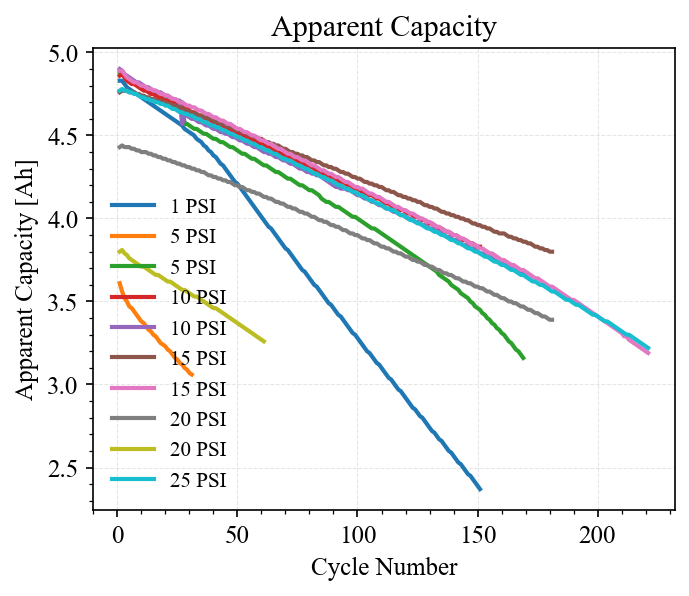

In [20]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
for cell in range(26,36):
    cell_no = f'{cell:02d}'
    df1 = pd.read_csv(eSOH_DIR + "aging_param_cell_" + cell_no + ".csv")
    ax.plot(df1["N"],df1["App Cap [Ah]"])
ax.legend(["1 PSI","5 PSI","5 PSI","10 PSI","10 PSI","15 PSI","15 PSI","20 PSI","20 PSI","25 PSI"])
ax.set_xlabel("Cycle Number")
ax.set_ylabel("Apparent Capacity [Ah]")
ax.set_title("Apparent Capacity")
plt.savefig(fig_DIR + "Apparent Cap All.png")

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
for cell in range(26,36):
    cell_no = f'{cell:02d}'
    df1 = pd.read_csv(eSOH_DIR + "aging_param_cell_" + cell_no + ".csv")
    ax.plot(df1["N"],df1["Min Exp [mu m]"])
ax.legend(["1 PSI","5 PSI","5 PSI","10 PSI","10 PSI","15 PSI","15 PSI","20 PSI","20 PSI","25 PSI"])
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"Irreversible Expansion [$\mu$m]")
ax.set_title("Irreversible Expansion")
plt.savefig(fig_DIR + "Expansion All.png")

In [ ]:
df1.columns

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
for cell in range(26,36):
    cell_no = f'{cell:02d}'
    df1 = pd.read_csv(eSOH_DIR + "aging_param_cell_" + cell_no + ".csv")
    ax.plot(df1["N"],df1["Rs [ohm]"])
ax.legend(["1 PSI","5 PSI","5 PSI","10 PSI","10 PSI","15 PSI","15 PSI","20 PSI","20 PSI","25 PSI"])
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"Resistance [$\Omega$]")
ax.set_title("Resistance")
plt.savefig(fig_DIR + "Resistance All.png")

In [24]:
cells = [1,4,7,10]

(1.0, 5.0)

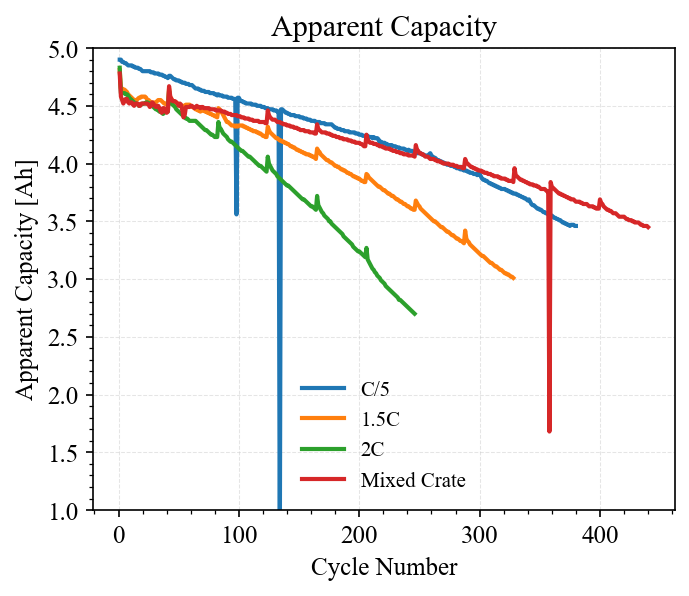

In [26]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
for cell in cells:
    cell_no = f'{cell:02d}'
    df1 = pd.read_csv(eSOH_DIR + "aging_param_cell_cyc_" + cell_no + ".csv")
    ax.plot(df1["N"],df1["App Cap [Ah]"])
ax.legend(["C/5","1.5C","2C","Mixed Crate"])
ax.set_xlabel("Cycle Number")
ax.set_ylabel("Apparent Capacity [Ah]")
ax.set_title("Apparent Capacity")
ax.set_ylim(1,5)
# plt.savefig(fig_DIR + "Apparent Cap All.png")

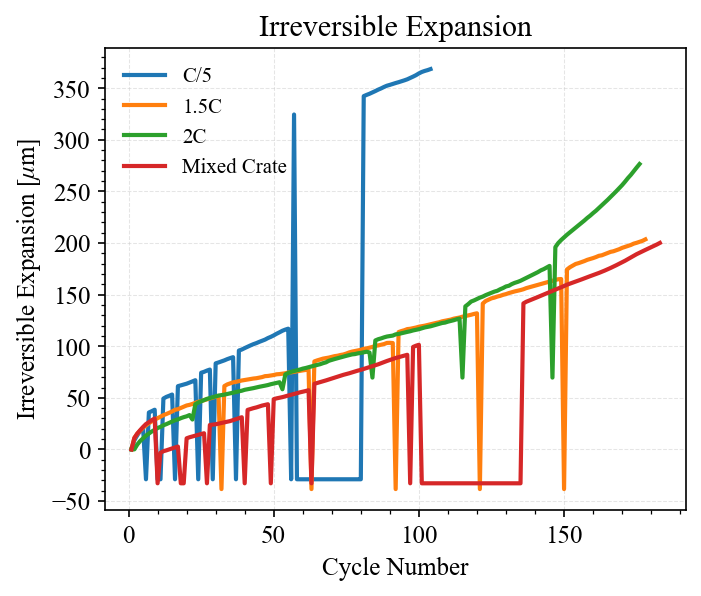

In [17]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
for cell in cells:
    cell_no = f'{cell:02d}'
    df1 = pd.read_csv(eSOH_DIR + "aging_param_cell_cyc_" + cell_no + ".csv")
    ax.plot(df1["N"],df1["Min Exp [mu m]"])
ax.legend(["C/5","1.5C","2C","Mixed Crate"])
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"Irreversible Expansion [$\mu$m]")
ax.set_title("Irreversible Expansion")
plt.savefig(fig_DIR + "Expansion All.png")

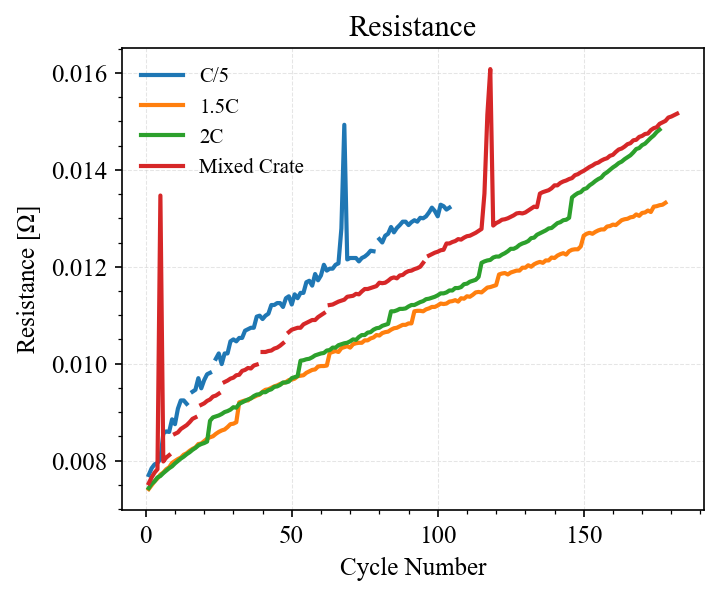

In [18]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
for cell in cells:
    cell_no = f'{cell:02d}'
    df1 = pd.read_csv(eSOH_DIR + "aging_param_cell_cyc_" + cell_no + ".csv")
    ax.plot(df1["N"],df1["Rs [ohm]"])
ax.legend(["C/5","1.5C","2C","Mixed Crate"])
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"Resistance [$\Omega$]")
ax.set_title("Resistance")
plt.savefig(fig_DIR + "Resistance All.png")